# Molecular Solubility Prediction using Machine Learning
# To predict the solubility ("logs") of molecules based on their structural and chemical features without relying on lab experiments.

In [5]:
# Installing RDKit library for cheminformatics operations
!pip install rdkit
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
print("--- Phase 1: Data Fetching ---")
# load original dataset directly from DeepChem
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
dataset = pd.read_csv(url)
dataset=dataset[['smiles','measured log solubility in mols per litre']]# keep only SMILES and target logs
dataset.columns=['smiles','logs']# rename for easier access

print(f"Data Ready ! Total molecules:{len(dataset)}") 
print("\n--- Phase 2: Feature Extraction ---")

mol_weights = []

# calculate MolWt for each molecule
for smiles_code in dataset['smiles']:
    mol=Chem.MolFromSmiles(smiles_code)
    weight=Descriptors.MolWt(mol)
    mol_weights.append(weight)
print("Molecular Weight calculation complete!")
print("First 5 weights:", mol_weights[:5])

--- Phase 1: Data Fetching ---
Data Ready ! Total molecules:1128

--- Phase 2: Feature Extraction ---
Molecular Weight calculation complete!
First 5 weights: [457.4320000000001, 201.22500000000002, 152.237, 278.354, 84.14299999999999]


In [10]:
import os
print(os.getcwd())


/home/ashik101ab


### Step 2: Extracting Partition Coefficient (LogP)
LogP measures a molecule's lipophilicity (how well it dissolves in lipids vs. water). It is a critical feature for predicting aqueous solubility.

In [6]:
mol_logp=[]
# calculate LogP (lipophilicity) for each molecule
for smiles_code in dataset['smiles']:
    mol=Chem.MolFromSmiles(smiles_code)
    logp=Descriptors.MolLogP(mol)
    mol_logp.append(logp)
print("first 5 logp:",mol_logp[:5])


first 5 logp: [-3.1080199999999985, 2.840320000000001, 2.878000000000001, 6.299400000000004, 1.7480999999999998]


### Step3: Baseline Model Evaluation (Linear Regression)
Testing a basic linear regression model using only two features (Molecular Weight and LogP) to establish a baseline R^2 score before moving to complex models.

In [7]:
# append extracted features to the main dataset
dataset['Molecular_Weight'] = mol_weights
dataset['LogP'] = mol_logp
print("Current Columns in dataset:", dataset.columns)
!pip install scikit-learn
from sklearn.linear_model import LinearRegression 
# define features (X) and target solubility (Y)
X=dataset[['Molecular_Weight','LogP']]
Y=dataset['logs']
model = LinearRegression()
model.fit(X,Y)
accuracy=model.score(X,Y)
print(accuracy)

Current Columns in dataset: Index(['smiles', 'logs', 'Molecular_Weight', 'LogP'], dtype='str')
0.7633149876905535


### Step 4: Extracting Advanced Structural Descriptors
Extracting four additional chemical features (H-Donors, H-Acceptors, Rotatable Bonds, and Ring Counts). 
These structural properties dictate hydrogen bonding capabilities and molecular flexibility, which are critical for determining aqueous solubility.

In [8]:
h_donors=[]
h_acceptors=[]
rot_bonds=[]
rings=[]
# extract structural features for each molecule
for smile_code in dataset['smiles']:
    mol=Chem.MolFromSmiles(smiles_code)
    # calculate and append descriptors
    h_donors.append(Descriptors.NumHDonors(mol))
    h_acceptors.append(Descriptors.NumHAcceptors(mol))
    rot_bonds.append(Descriptors.NumRotatableBonds(mol))
    rings.append(Descriptors.RingCount(mol))
print("Feature Extractioni Complete!Sensor data ready.")

Feature Extractioni Complete!Sensor data ready.


### Step 5: Updated Baseline Model (6 Features)
Adding the newly extracted structural features (H-Donors, H-Acceptors, Rotatable Bonds, Ring Counts) to the main dataset. Re-training the linear regression model to check if expanding the feature space improves the linear correlation with solubility.

In [9]:
#append new structural features to the datasetdataset['H_Donors']=h_donors
dataset['H_Acceptors']=h_acceptors
dataset['Rotatable_Bonds']=rot_bonds
dataset['Ring_counts']=rings
# update feature matrix X with all 6 descriptors
X=dataset[['Molecular_Weight','LogP','H_Donors','H_Acceptors','Rotatable_Bonds','Ring_counts']]
Y=dataset['logs']
from sklearn.linear_model import LinearRegression
# train linear regression on the expanded feature set
model = LinearRegression()
model.fit(X,Y)


new_accuracy=model.score(X,Y)
print("....performance update....")
print(f"New R^2 score (6 feature):{new_accuracy:.4f}")


....performance update....
New R^2 score (6 feature):0.7633


### Step 6: Non-Linear Modeling (The Overfitting Trap)
Applying a Random Forest Regressor to the entire dataset. 
**Note:** Training and evaluating on the exact same dataset is a bad practice as it leads to severe overfitting.
The high accuracy here is artificial because the model has simply memorized the data.

In [10]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
# train the model on 100% of the data (flawed approach)
rf_model.fit(X,Y)
rf_accuracy = rf_model.score(X, Y)
print(f"Random Forest R^2 score (6 features): {rf_accuracy:.4f}")

Random Forest R^2 score (6 features): 0.9771


### Step 7: True Model Evaluation (Train-Test Split)
Splitting the dataset (80% train, 20% test) to evaluate the Random Forest model on completely unseen data. This prevents overfitting and reveals the true predictive capability of the model for molecular solubility.

In [14]:
from sklearn.model_selection import train_test_split
# splitting data into 80% train and 20% test sets)
X_train ,X_test,Y_train,Y_Test = train_test_split(X,Y,test_size=0.20,random_state=42)
print(f"Training data size:{X_train.shape[0]}molecules")
print(f"Testing data size:{X_test.shape[0]}molecules")
rf_model_real = RandomForestRegressor(random_state=42)
rf_model_real.fit(X_train, Y_train)
real_accuracy = rf_model_real.score(X_test, Y_Test)
print(f"Real Random Forest R^2 score (Unseen Data): {real_accuracy:.4f}")

Training data size:902molecules
Testing data size:226molecules
Real Random Forest R^2 score (Unseen Data): 0.8406


### Step 6: Visualizing Model Performance (Actual vs Predicted)
Generating a scatter plot to visually compare the actual experimental solubility values against the Random Forest predictions. A perfect model would align all points perfectly on the diagonal red dashed line.

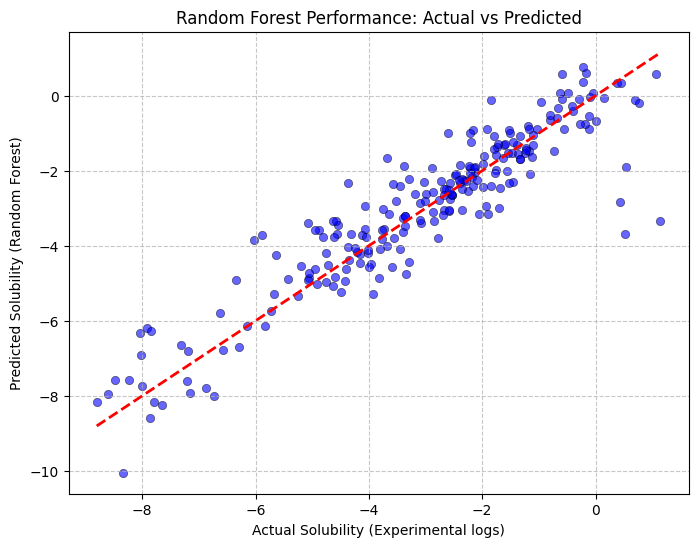

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# generate predictions on the unseen testing data
predictions = rf_model_real.predict(X_test)

# initialize the plotting canvas
plt.figure(figsize=(8, 6))

# plot actual vs predicted values using a scatter plot
sns.scatterplot(x=Y_Test, y=predictions, alpha=0.6, color='blue', edgecolor='k')

# draw the baseline y=x reference line for perfect predictions
plt.plot([Y_Test.min(), Y_Test.max()], [Y_Test.min(), Y_Test.max()], color='red', linestyle='--', linewidth=2)

# apply professional formatting and labels
plt.xlabel("Actual Solubility (Experimental logs)")
plt.ylabel("Predicted Solubility (Random Forest)")
plt.title("Random Forest Performance: Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.7)

# render the final visualization
plt.show()